# Imports

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("darkgrid")

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.19 (you have 1.4.16). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
np.random.seed(42)
torch.manual_seed(42)

# Configuration

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

train_dir = PROJECT_ROOT / "train" / "training"
val_dir   = PROJECT_ROOT / "train" / "validation"
test_dir  = PROJECT_ROOT / "train" / "testing"

classes = ['Empty', 'High', 'Low', 'Medium', 'Traffic Jam']

batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]


# Image Augmentation

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(rotate_limit=5, value=0, border_mode=cv2.BORDER_CONSTANT),

    A.OneOf([
        A.CLAHE(),
        A.RandomBrightnessContrast(),
        A.HueSaturationValue()
    ], p=1),

    A.GaussNoise(),
    A.RandomResizedCrop(height=400, width=600),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=400, width=600),
    A.Normalize(),
    ToTensorV2()
])


In [ ]:
def open_img(img_path):
    img = Image.open(img_path)
    img = np.array(img)
    if img.shape[2] == 3:
        return img
    else:
        return img[:, :, :-1]

class Transform():
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        return self.transform(image=image)["image"]


# Dataset

In [ ]:
from pathlib import Path
from torchvision.datasets import ImageFolder

PROJECT_ROOT = Path.cwd()

train_dir = PROJECT_ROOT / "train" / "training"
val_dir   = PROJECT_ROOT / "train" / "validation"
test_dir  = PROJECT_ROOT / "train" / "testing"

# Create datasets
train_ds = ImageFolder(train_dir, transform=Transform(train_transform), loader=open_img)
val_ds   = ImageFolder(val_dir, transform=Transform(val_transform), loader=open_img)
test_ds  = ImageFolder(test_dir, transform=Transform(val_transform), loader=open_img)


In [ ]:
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=os.cpu_count(),
    pin_memory=True if device == "cuda" else False
)

val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=True if device == "cuda" else False
)

test_dl = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=os.cpu_count(),
    pin_memory=True if device == "cuda" else False
)


# Data Visualization

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12,16))
ax = axes.flatten()

imgs, labels = next(iter(train_dl))

for i, img in enumerate(imgs):
    img = img.cpu()   # ← important fix
    imgp = np.transpose(img.numpy(), (1,2,0)) * std + mean
    ax[i].imshow(imgp)
    ax[i].set_title(classes[labels[i].item()])
    ax[i].axis("off")


# Training

In [ ]:
def get_lr(optimizer):
    for params in optimizer.param_groups:
        return params["lr"]


def training(model, epochs, train_dl, val_dl, optimizer, lr_scheduler, loss_fn, weights_path):
    
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    loss_dict = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    
    for epoch in range(epochs):

        train_loss, train_correct = 0.0, 0
        val_loss, val_correct = 0.0, 0
        
        train_len = len(train_dl.dataset)
        val_len   = len(val_dl.dataset)

        model.train()
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(imgs)
            loss = loss_fn(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (output.argmax(1) == labels).sum().item()

        model.eval()
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                output = model(imgs)
                loss = loss_fn(output, labels)

                val_loss += loss.item()
                val_correct += (output.argmax(1) == labels).sum().item()

        train_acc = train_correct / train_len
        val_acc   = val_correct / val_len

        lr_scheduler.step(val_loss / val_len)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            print("Updating Best Model Weights")

        loss_dict["train_loss"].append(train_loss/train_len)
        loss_dict["train_acc"].append(train_acc)
        loss_dict["val_loss"].append(val_loss/val_len)
        loss_dict["val_acc"].append(val_acc)

        print(f"{epoch+1}/{epochs} | Train Loss: {train_loss/train_len:.4f} | Train Acc: {train_acc:.4f}")
        print(f"{epoch+1}/{epochs} | Val Loss: {val_loss/val_len:.4f} | Val Acc: {val_acc:.4f}")
        print("-"*50)

    torch.save(best_weights, weights_path)
    return loss_dict


In [ ]:
def get_model(weights=None):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features=in_features, out_features=5)
    model.to(device)
    return model


# Transfer Learning as Feature Extractor

In [ ]:
weights = EfficientNet_B0_Weights.DEFAULT
model = get_model(weights)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-3dd342df.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-3dd342df.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 48.8MB/s]


In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=7,
    threshold=0.0001
)

loss_fn = nn.CrossEntropyLoss()

extractor_weights_path = "extractor_model.pth"


In [ ]:
loss_dict = training(
    model,
    25,
    train_dl,
    val_dl,
    optimizer,
    lr_scheduler,
    loss_fn,
    extractor_weights_path
)


Updating Best Model weights
1/25: Training
loss: 1.1391128017183871 accuracy: 0.53700414446418
1/25: Evaluating
loss: 0.73456312417984 accuracy: 0.7235294117647059
************************************************** 

2/25: Training
loss: 0.9568569779466637 accuracy: 0.6080521018354056
2/25: Evaluating
loss: 0.6903042849372415 accuracy: 0.711764705882353
************************************************** 

Updating Best Model weights
3/25: Training
loss: 0.8963694055098764 accuracy: 0.6370633510953226
3/25: Evaluating
loss: 0.6443678613971261 accuracy: 0.7294117647058823
************************************************** 

Updating Best Model weights
4/25: Training
loss: 0.8848872854555762 accuracy: 0.6326228537596211
4/25: Evaluating
loss: 0.6139317505499896 accuracy: 0.7470588235294118
************************************************** 

5/25: Training
loss: 0.8786422503354494 accuracy: 0.6474245115452931
5/25: Evaluating
loss: 0.6388903263737173 accuracy: 0.7264705882352941
*********

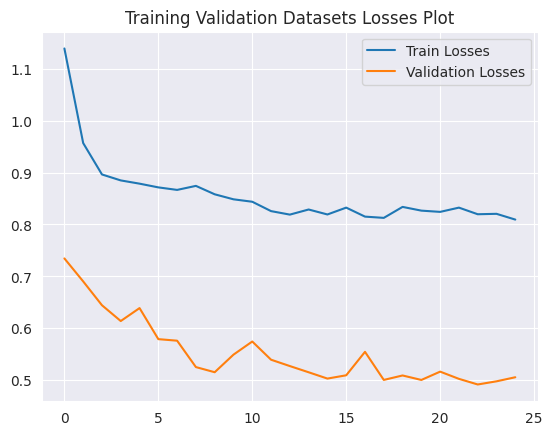

In [ ]:
x = range(len(loss_dict['train_loss']))

sns.lineplot(x=x, y=loss_dict['train_loss'], label="Train Losses")
sns.lineplot(x=x, y=loss_dict['val_loss'], label="Validation Losses")

plt.title("Training Validation Datasets Losses Plot")
plt.legend()
plt.show()


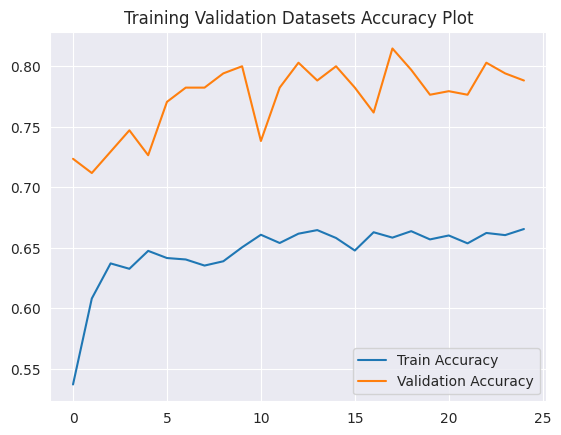

In [ ]:
sns.lineplot(x=x, y=loss_dict['train_acc'], label="Train Accuracy")
sns.lineplot(x=x, y=loss_dict['val_acc'], label="Validation Accuracy")

plt.title("Training Validation Datasets Accuracy Plot")
plt.legend()
plt.show()


# Transfer Learning with Fine Tuning

In [ ]:
model = get_model()
model.load_state_dict(torch.load("extractor_model.pth"))


<All keys matched successfully>

In [ ]:
# Unfreeze entire model
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-4)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=7,
    threshold=0.0001
)

loss_fn = nn.CrossEntropyLoss()

finetuning_weights_path = "finetuning_model.pth"


In [ ]:
loss_dict = training(
    model,
    50,
    train_dl,
    val_dl,
    optimizer,
    lr_scheduler,
    loss_fn,
    finetuning_weights_path
)


Updating Best Model weights
1/50: Training
loss: 0.7790569701160885 accuracy: 0.6823564239194789
1/50: Evaluating
loss: 0.45847146309473935 accuracy: 0.8235294117647058
************************************************** 

2/50: Training
loss: 0.7392375943504049 accuracy: 0.6983422143280047
2/50: Evaluating
loss: 0.43358091063359205 accuracy: 0.8205882352941176
************************************************** 

Updating Best Model weights
3/50: Training
loss: 0.6750216630302356 accuracy: 0.7276494967436353
3/50: Evaluating
loss: 0.4016095354276545 accuracy: 0.8294117647058824
************************************************** 

Updating Best Model weights
4/50: Training
loss: 0.6508859896038749 accuracy: 0.7386027235050325
4/50: Evaluating
loss: 0.38008156585342745 accuracy: 0.8470588235294118
************************************************** 

Updating Best Model weights
5/50: Training
loss: 0.6412822286217363 accuracy: 0.7353463587921847
5/50: Evaluating
loss: 0.3700747563996736 ac

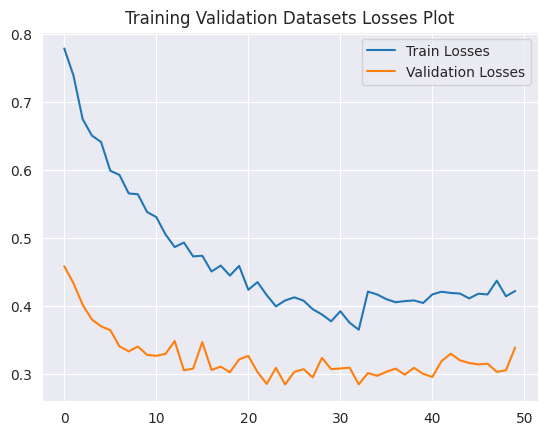

In [ ]:
x = range(len(loss_dict['train_loss']))

sns.lineplot(x=x, y=loss_dict['train_loss'], label="Train Losses")
sns.lineplot(x=x, y=loss_dict['val_loss'], label="Validation Losses")

plt.title("Training Validation Datasets Losses Plot")
plt.legend()
plt.show()


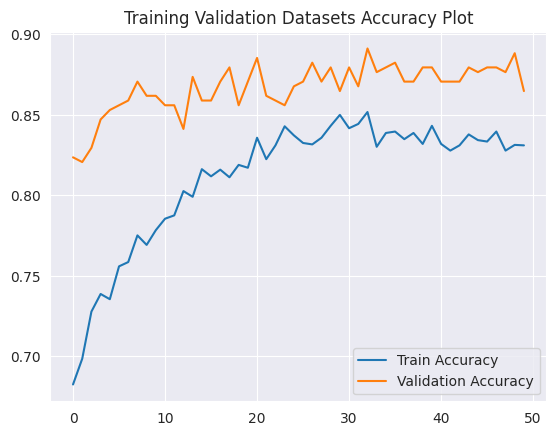

In [ ]:
sns.lineplot(x=x, y=loss_dict['train_acc'], label="Train Accuracy")
sns.lineplot(x=x, y=loss_dict['val_acc'], label="Validation Accuracy")

plt.title("Training Validation Datasets Accuracy Plot")
plt.legend()
plt.show()


# Evaluation

In [ ]:
model = get_model()
model.load_state_dict(torch.load("finetuning_model.pth"))
model.to(device)


<All keys matched successfully>

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12,16))
plt.subplots_adjust(wspace=0)
ax = axes.flatten()

imgs, labels = next(iter(test_dl))

model.eval()
with torch.no_grad():
    imgs = imgs.to(device)
    output = model(imgs)

for i in range(imgs.shape[0]):
    pred_label = output[i].argmax(0)

    ax[i].imshow(
        imgs[i].permute(1,2,0).cpu().numpy() * std + mean
    )

    ax[i].text(
        10, 30, "True: " + classes[labels[i].item()],
        fontsize=12, color="green"
    )

    ax[i].text(
        300, 30, "Predict: " + classes[pred_label.item()],
        fontsize=12, color="red"
    )

    ax[i].axis("off")

plt.savefig("prediction_samples.png")
plt.show()


# Inference

In [ ]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        output = model(imgs)
        pred_labels = output.argmax(dim=1)

        y_true += labels.cpu().tolist()
        y_pred += pred_labels.cpu().tolist()


In [ ]:
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.95      0.98        64
           1       0.90      0.94      0.92        64
           2       0.90      0.95      0.92        64
           3       0.89      0.88      0.88        64
           4       1.00      0.95      0.98        64

    accuracy                           0.93       320
   macro avg       0.94      0.93      0.93       320
weighted avg       0.94      0.93      0.93       320



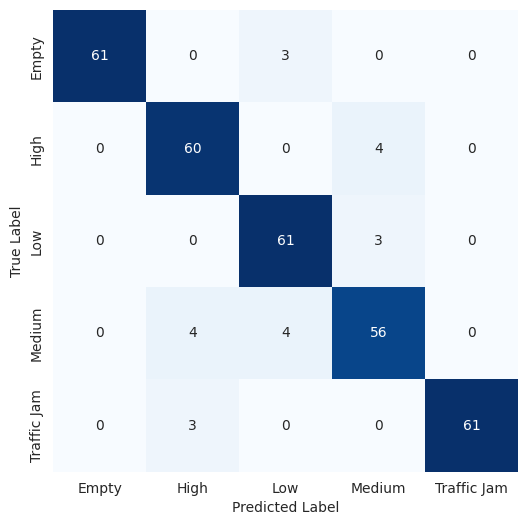

In [ ]:
plt.figure(figsize=(6,6))

val = ['Empty', 'High', 'Low', 'Medium', 'Traffic Jam']
plot_data = pd.DataFrame(
    confusion_matrix(y_true, y_pred),
    columns=val,
    index=val
)

sns.heatmap(plot_data, annot=True, cbar=False, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("confusion_matrix.png")
plt.show()
